# 🤖 Fase de Modelado Predictivo (Clasificación)
En esta etapa, pasamos del Análisis Exploratorio (EDA) a la **Inteligencia Artificial Aplicada**. 
El objetivo es construir un modelo capaz de predecir la supervivencia de un pasajero basándose en patrones históricos.

### Conceptos Clave de esta Fase:
1. **Feature Engineering Final:** Transformar datos categóricos (texto) en tensores numéricos.
2. **Data Splitting:** Dividir el "universo" de datos en un grupo de **Entrenamiento** (donde la IA estudia) y uno de **Prueba** (donde evaluamos su inteligencia real).
3. **Random State:** Usamos la semilla `42` para que los resultados sean reproducibles (que no cambien cada vez que des al 'Play').

**Ruta de Datos:** `../../../data/processed/titanic_limpio.csv` (Subimos 3 niveles desde `notebooks/datos/titanic/`).

In [1]:
import pandas as pd
import numpy as np

# 1. CARGA DEL DATASET PURIFICADO (BÚNKER)
# Usamos la ruta de 3 niveles rectificada según tu estructura de carpetas
path_limpio = '../../../data/processed/titanic_limpio.csv'
df = pd.read_csv(path_limpio)

# 2. ENCODING BINARIO (COLUMNA SEXO)
# Los algoritmos matemáticos no entienden "hombre" o "mujer". 
# .map() asigna 1 a 'male' y 0 a 'female'. Esto se llama Label Encoding.
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

# 3. ONE-HOT ENCODING (PUERTO DE EMBARQUE)
# Como hay 3 puertos (C, Q, S), no podemos usar 0, 1, 2 porque la IA creería que el 2 vale más que el 0.
# pd.get_dummies crea 3 columnas nuevas (Port_C, Port_Q, Port_S) con ceros y unos.
df = pd.get_dummies(df, columns=['Embarked'], prefix='Port')

# 4. LIMPIEZA DE COLUMNAS DE ANÁLISIS (DATA WRANGLING PARA IA)
# 'AgeGroup' fue útil para gráficas, pero para el modelo la edad numérica ('Age') es más precisa.
if 'AgeGroup' in df.columns:
    df.drop('AgeGroup', axis=1, inplace=True)

# 5. VERIFICACIÓN DE LA TABLA "MÁQUINA"
print("--- Dataset transformado para el Algoritmo ---")
display(df.head()) # Verificamos que todo sea numérico (int64, float64 o bool/uint8)
print(f"\nDimensiones actuales: {df.shape}")

--- Dataset transformado para el Algoritmo ---


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Port_C,Port_Q,Port_S
0,0,3,1,22.0,1,0,7.2500,False,False,True
1,1,1,0,38.0,1,0,71.2833,True,False,False
2,1,3,0,26.0,0,0,7.9250,False,False,True
3,1,1,0,35.0,1,0,53.1000,False,False,True
4,0,3,1,35.0,0,0,8.0500,False,False,True



Dimensiones actuales: (891, 10)


## ⚖️ Estrategia de Evaluación: El Examen Ciego
Para evitar el **Overfitting** (que la IA memorice en lugar de aprender), dividimos el dataset:

* **X (Features):** Son las "preguntas" del examen (Clase, Sexo, Edad, Familia...).
* **y (Target):** Es la "respuesta" correcta (¿Sobrevivió? 0 o 1).

Utilizaremos un **80% de los datos para entrenar** y un **20% para testear**, simulando pasajeros "nuevos" que el modelo nunca ha visto.

In [2]:
from sklearn.model_selection import train_test_split # La herramienta estándar de oro

# 1. SEPARACIÓN DE X (PREDICTORES) e Y (OBJETIVO)
# X: Quitamos la columna 'Survived' porque no queremos que la IA vea la respuesta.
X = df.drop('Survived', axis=1)

# y: Seleccionamos solo la columna que queremos predecir.
y = df['Survived']

# 2. DIVISIÓN ALEATORIA CONTROLADA (TRAIN/TEST SPLIT)
# test_size=0.20: Reservamos el 20% (aprox 178 pasajeros) para el examen final.
# random_state=42: "Semilla mágica" para que a ti y a mí nos salgan los mismos números.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. REPORTE DE ESTRUCTURA
print("✅ División finalizada con éxito:")
print(f"🔹 Pasajeros para Entrenamiento (Estudio): {X_train.shape[0]}")
print(f"🔹 Pasajeros para Prueba (Examen): {X_test.shape[0]}")
print(f"🔹 Número de variables por pasajero: {X_train.shape[1]}")

✅ División finalizada con éxito:
🔹 Pasajeros para Entrenamiento (Estudio): 712
🔹 Pasajeros para Prueba (Examen): 179
🔹 Número de variables por pasajero: 9


## 🌲 El Bosque Aleatorio (Random Forest Classifier)
Para este caso usaremos **Random Forest**, un algoritmo de "Sabiduría de Masas". 
Crea múltiples árboles de decisión y hace que voten entre ellos para decidir si el pasajero sobrevive o no. 

Es uno de los modelos más robustos y potentes para datos tabulares como el del Titanic.

In [3]:
from sklearn.ensemble import RandomForestClassifier # Importamos el "Bosque"

# 1. INSTANCIACIÓN DEL MODELO
# n_estimators=100: Le pedimos que cree 100 árboles de decisión diferentes.
# max_depth=5: Limitamos la profundidad para que no se "obsesione" con detalles irrelevantes.
modelo_titanic = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 2. ENTRENAMIENTO (FIT)
# Aquí es donde ocurre la magia: el modelo estudia X_train y y_train para buscar patrones.
modelo_titanic.fit(X_train, y_train)

# 3. PREDICCIÓN (EXAMEN)
# Le pedimos al modelo que intente adivinar el resultado de los datos de prueba (X_test).
predicciones = modelo_titanic.predict(X_test)

print("🌲 ¡Modelo entrenado y predicciones generadas con éxito!")

🌲 ¡Modelo entrenado y predicciones generadas con éxito!


## 📊 Evaluación de Resultados: ¿Qué tan buena es nuestra IA?
Un modelo de Machine Learning no se mide solo por "acertar", sino por **dónde falla**.
Conceptos clave de esta celda:
1. **Precisión (Accuracy):** El porcentaje total de aciertos sobre el total de casos.
2. **Matriz de Confusión:** Una tabla que nos dice:
   - **Verdaderos Positivos (VP):** Gente que dijimos que sobrevivía y sobrevivió.
   - **Falsos Positivos (FP):** Gente que dijimos que sobrevivía pero falleció (Error tipo I).
   - **Verdaderos Negativos (VN):** Gente que dijimos que fallecía y falleció.
   - **Falsos Negativos (FN):** Gente que dijimos que fallecía pero sobrevivió (Error tipo II).

🎯 Precisión Global del Modelo: 81.56% (Porcentaje de aciertos)


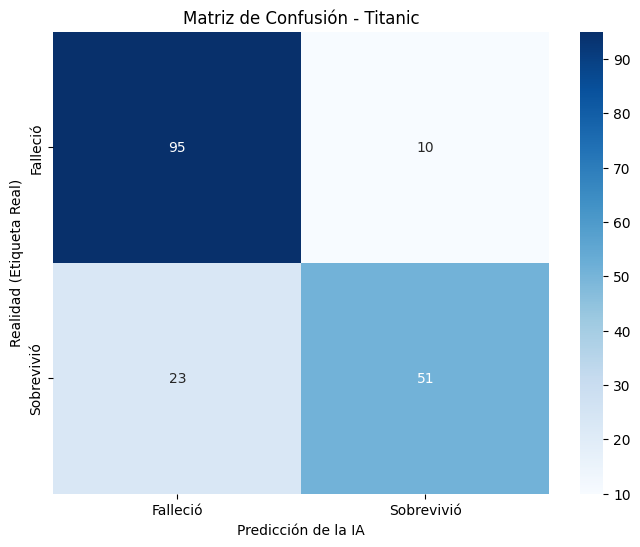


--- Reporte de Clasificación Completo ---
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



In [4]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. CÁLCULO DE LA PRECISIÓN GLOBAL
# Comparamos las 'predicciones' de la IA con la realidad ('y_test')
accuracy = accuracy_score(y_test, predicciones)
print(f"🎯 Precisión Global del Modelo: {accuracy:.2%} (Porcentaje de aciertos)")

# 2. CREACIÓN DE LA MATRIZ DE CONFUSIÓN
# Esta matriz cruza la realidad contra la predicción
conf_matrix = confusion_matrix(y_test, predicciones)

# 3. VISUALIZACIÓN ELEGANTE (HEATMAP)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Falleció', 'Sobrevivió'], 
            yticklabels=['Falleció', 'Sobrevivió'])

plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad (Etiqueta Real)')
plt.title('Matriz de Confusión - Titanic')
plt.show()

# 4. REPORTE DETALLADO (RECALL, PRECISION, F1)
# Nos da el desglose por cada clase (0 y 1)
print("\n--- Reporte de Clasificación Completo ---")
print(classification_report(y_test, predicciones))

## 🔍 ¿En qué se fijó la IA para decidir? (Feature Importance)
Una de las mayores ventajas del **Random Forest** es que no es una "caja negra". Podemos preguntarle qué columnas fueron las más determinantes para predecir la supervivencia. 
¿Fue más importante el **Sexo**, la **Clase** o la **Edad**? Aquí lo descubriremos.

C:\Users\txema\AppData\Local\Temp\ipykernel_11428\1150592453.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_imp, palette='magma')


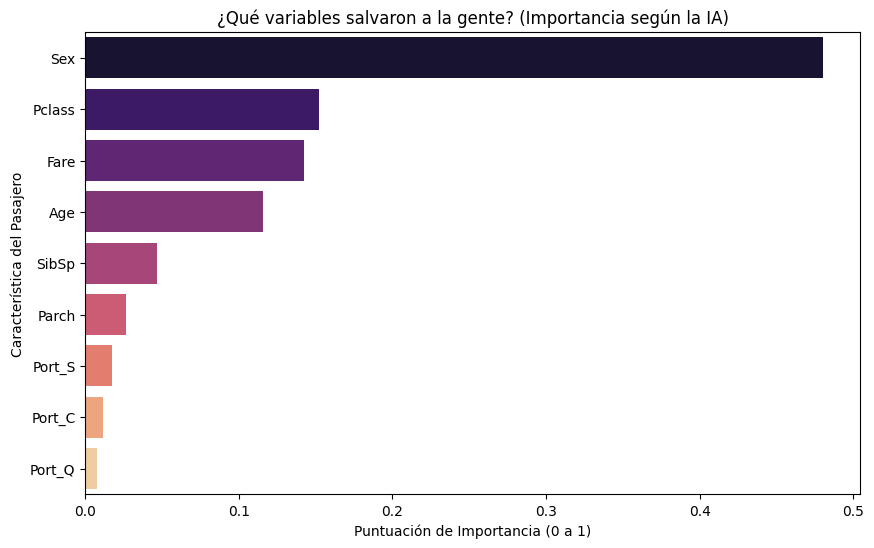

💡 La variable más influyente para tu modelo fue: Sex


In [5]:
# 1. EXTRACCIÓN DE IMPORTANCIAS
# El modelo ya tiene guardado cuánto "peso" le dio a cada columna en el entrenamiento
importancias = modelo_titanic.feature_importances_
columnas = X.columns

# 2. CREACIÓN DE UN DATAFRAME PARA VISUALIZAR
# Ordenamos de mayor a menor importancia
feature_imp = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
feature_imp = feature_imp.sort_values(by='Importancia', ascending=False)

# 3. GRÁFICO DE BARRAS HORIZONTALES
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feature_imp, palette='magma')

plt.title('¿Qué variables salvaron a la gente? (Importancia según la IA)')
plt.xlabel('Puntuación de Importancia (0 a 1)')
plt.ylabel('Característica del Pasajero')
plt.show()

# 4. CONCLUSIÓN TÉCNICA
variable_top = feature_imp.iloc[0]['Variable']
print(f"💡 La variable más influyente para tu modelo fue: {variable_top}")

## 💾 Persistencia del Modelo: Guardado en Disco
Una vez que estamos satisfechos con la precisión de nuestro **Random Forest**, debemos "congelarlo" y guardarlo. 
Esto nos permite:
1. **Reutilizarlo:** Cargar el modelo en una aplicación web o en otro notebook sin tener que entrenar de nuevo.
2. **Escalabilidad:** Separar la fase de entrenamiento de la fase de predicción real.
3. **Control de Versiones:** Guardar diferentes modelos (v1, v2) para comparar cuál es mejor en el futuro.

Utilizaremos la librería `joblib`, que es la más eficiente para manejar objetos pesados de Machine Learning en Python.

In [6]:
import joblib # Librería especializada en serialización de modelos de IA
import os

# 1. DEFINICIÓN DE LA RUTA DE GUARDADO (3 NIVELES HACIA ARRIBA)
# Recordatorio: notebooks/datos/titanic/ -> ../../../ nos deja en la raíz del proyecto
folder_modelos = '../../../models/'
model_name = 'random_forest_titanic_v1.pkl'
path_final = os.path.join(folder_modelos, model_name)

# 2. CREACIÓN DE LA CARPETA (POR SEGURIDAD)
# Si la carpeta 'models' no existe en la raíz, el código la crea automáticamente
os.makedirs(folder_modelos, exist_ok=True)

# 3. EXPORTACIÓN DEL MODELO (SERIALIZACIÓN)
# Guardamos el objeto 'modelo_titanic' que ya contiene todo el aprendizaje
joblib.dump(modelo_titanic, path_final)

# 4. AUDITORÍA DE ÉXITO
if os.path.exists(path_final):
    size_kb = os.path.getsize(path_final) / 1024
    print(f"✅ MODELO GUARDADO CON ÉXITO: {model_name}")
    print(f"📦 Tamaño en disco: {size_kb:.2f} KB")
    print(f"📍 Ubicación confirmada: {os.path.abspath(path_final)}")
else:
    print("❌ ERROR: El modelo no se pudo guardar. Revisa los permisos de escritura.")

✅ MODELO GUARDADO CON ÉXITO: random_forest_titanic_v1.pkl
📦 Tamaño en disco: 399.82 KB
📍 Ubicación confirmada: c:\Users\txema\Documents\IA_Especialista\models\random_forest_titanic_v1.pkl


## 🧪 Test de Carga: Diagnóstico y Predicción Final
Para solucionar el error de dimensiones, primero vamos a imprimir el orden exacto de las columnas que el modelo espera. 
Luego, ajustaremos nuestro **pasajero ficticio** para que coincida perfectamente con la estructura del "cerebro" de la IA.

In [8]:
import joblib
import pandas as pd

# 1. CARGAMOS EL MODELO
modelo_cargado = joblib.load('../../../models/random_forest_titanic_v1.pkl')

# 2. IDENTIFICACIÓN DE COLUMNAS (EL "TRUCO" DEL ESPECIALISTA)
# Le preguntamos al modelo qué nombres de columnas espera exactamente
columnas_esperadas = modelo_cargado.feature_names_in_
print(f"📋 El modelo espera estas {len(columnas_esperadas)} variables:")
print(columnas_esperadas)

# 3. CREAMOS UN PASAJERO QUE COINCIDA (EJEMPLO AJUSTADO)
# Vamos a crear un DataFrame en lugar de una lista simple. 
# Esto evita errores de orden y cantidad automáticamente.
datos_pasajero = {
    'Pclass': [3],
    'Sex': [1],      # 1 para Hombre
    'Age': [22.0],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [7.25],
    'IsAlone': [1],
    'Port_C': [0],   # No embarcó en Cherbourg
    'Port_Q': [0],   # No embarcó en Queenstown
    'Port_S': [1]    # Sí embarcó en Southampton
}

# Convertimos a DataFrame y nos aseguramos de que SOLO tenga las columnas del modelo
pasajero_final = pd.DataFrame(datos_pasajero)

# IMPORTANTE: Reordenamos las columnas para que coincidan con el entrenamiento
pasajero_final = pasajero_final[columnas_esperadas]

# 4. PREDICCIÓN
resultado = modelo_cargado.predict(pasajero_final)
probabilidades = modelo_cargado.predict_proba(pasajero_final)

# 5. RESULTADO FINAL
print("\n--- Resultado de la Predicción ---")
if resultado[0] == 1:
    print(f"🚢 Predicción: EL PASAJERO SOBREVIVIRÍA")
else:
    print(f"🌊 Predicción: EL PASAJERO NO SOBREVIVIRÍA")

print(f"📊 Probabilidad de éxito: {probabilidades[0][1]:.2%}")

📋 El modelo espera estas 9 variables:
['Pclass' 'Sex' 'Age' 'SibSp' 'Parch' 'Fare' 'Port_C' 'Port_Q' 'Port_S']

--- Resultado de la Predicción ---
🌊 Predicción: EL PASAJERO NO SOBREVIVIRÍA
📊 Probabilidad de éxito: 12.38%


## 🎮 Simulador Interactivo: "Tú en el Titanic"
Ahora que el modelo funciona, podemos cambiar los datos del pasajero para ver cómo cambian las probabilidades. 
Por ejemplo:
- ¿Qué pasa si el mismo pasajero fuera de **1ª Clase** (`Pclass: 1`)?
- ¿Qué pasa si cambiamos el género a **Mujer** (`Sex: 0`)?

In [9]:
# 1. DEFINE AQUÍ LOS DATOS DEL PASAJERO A PROBAR
# Cambia estos valores para experimentar:
clase_social = 1     # 1, 2 o 3
genero = 0           # 0 para Mujer, 1 para Hombre
edad = 25.0
hermanos_esposos = 1 # SibSp
padres_hijos = 0     # Parch
precio_ticket = 80.0 # Fare
puerto = 'Port_S'    # Puede ser 'Port_C', 'Port_Q' o 'Port_S'

# 2. CONSTRUCCIÓN AUTOMÁTICA DEL PASAJERO
# Creamos un diccionario con todas las columnas en 0.0 para permitir float/int sin conflicto de tipos.
nuevo_pasajero = {col: [0.0] for col in columnas_esperadas}

# Asignamos los valores manuales
nuevo_pasajero['Pclass'] = [clase_social]
nuevo_pasajero['Sex'] = [genero]
nuevo_pasajero['Age'] = [edad]
nuevo_pasajero['SibSp'] = [hermanos_esposos]
nuevo_pasajero['Parch'] = [padres_hijos]
nuevo_pasajero['Fare'] = [precio_ticket]

# Activamos el puerto elegido poniendo un 1
if puerto in nuevo_pasajero:
    nuevo_pasajero[puerto] = [1]

# 3. CONVERSIÓN Y PREDICCIÓN
df_simulacion = pd.DataFrame(nuevo_pasajero)[columnas_esperadas]
res_sim = modelo_cargado.predict(df_simulacion)
prob_sim = modelo_cargado.predict_proba(df_simulacion)

# 4. REPORTE VISUAL
print(f"--- Simulación para: {'Mujer' if genero==0 else 'Hombre'} en Clase {clase_social} ---")
if res_sim[0] == 1:
    print(f"🌟 Resultado: ¡SOBREVIVE! 🎉")
else:
    print(f"💀 Resultado: NO SOBREVIVE 🌊")

print(f"📈 Probabilidad de Supervivencia: {prob_sim[0][1]:.2%}")

# 4. REPORTE VISUAL
print(f"--- Simulación para: {'Mujer' if genero==0 else 'Hombre'} en Clase {clase_social} ---")
if res_sim[0] == 1:
    print(f"🌟 Resultado: ¡SOBREVIVE! 🎉")
else:
    print(f"💀 Resultado: NO SOBREVIVE 🌊")

print(f"📈 Probabilidad de Supervivencia: {prob_sim[0][1]:.2%}")

--- Simulación para: Mujer en Clase 1 ---
🌟 Resultado: ¡SOBREVIVE! 🎉
📈 Probabilidad de Supervivencia: 91.82%
--- Simulación para: Mujer en Clase 1 ---
🌟 Resultado: ¡SOBREVIVE! 🎉
📈 Probabilidad de Supervivencia: 91.82%
